In [ ]:
from dotenv import load_dotenv
load_dotenv(override=True)


True

# 기본 챗봇

In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
graph_builder

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gemma3:4b", temperature=0)

llm.invoke("안녕하세요")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요? 궁금한 점이 있거나, 필요한 정보가 있다면 언제든지 말씀해주세요. 😊\n', additional_kwargs={}, response_metadata={'model': 'gemma3:4b', 'created_at': '2026-01-08T03:21:26.8411147Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4246048800, 'load_duration': 3859981600, 'prompt_eval_count': 10, 'prompt_eval_duration': 37679700, 'eval_count': 27, 'eval_duration': 316113900, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'}, id='lc_run--019b9b9f-892d-7511-b7de-f541610de5f6-0', usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37})

In [4]:
def chatbot(state: State):
    "챗봇 노드 함수"
    
    response = llm.invoke(state["messages"])

    return {"messages": [response]}

graph_builder.add_node("chatbot", chatbot)

In [5]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

In [6]:
from uuid import uuid4
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

config = RunnableConfig(recursion_limit=20, thread_id=uuid4())

inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

stream_graph(graph, inputs, config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요! LangGraph에 대해 자세히 알려드리겠습니다. LangGraph는 2023년 11월에 공개된, **지식 그래프 기반의 대규모 언어 모델(LLM)**입니다. 기존 LLM의 한계를 극복하고, 지식 그래프의 강력한 연결성을 활용하여 더욱 정확하고 신뢰할 수 있는 답변을 제공하는 것을 목표로 합니다.

**1. LangGraph의 핵심 특징:**

*   **지식 그래프 기반:** LangGraph는 단순히 텍스트 데이터를 학습하는 것이 아니라, **지식 그래프(Knowledge Graph)**라는 구조화된 지식 데이터베이스를 기반으로 합니다. 지식 그래프는 엔티티(Entity, 예를 들어 사람, 장소, 개념)와 그들 간의 관계(Relationship, 예를 들어 "A는 B의 자식이다", "C는 D와 친구이다")를 명시적으로 표현합니다.
*   **Graph-Augmented Language Model (GALM):** LangGraph는 기존 LLM에 지식 그래프 정보를 추가하여 작동합니다. 이를 "Graph-Augmented Language Model" (GALM)이라고 부르며, LLM이 답변을 생성할 때 지식 그래프를 참조하여 답변의 정확성을 높입니다.
*   **추론 능력 강화:** 지식 그래프를 활용하여 LangGraph는 단순히 텍스트를 기반으로 답변하는 것을 넘어, **추론(Reasoning)** 능력을 향상시켰습니다. 예를 들어, "A는 B의 자식이고, B는 C의 자식이라면, A는 C의 손자입니까?"와 같은 질문에 대해 정확하게 답변할 수 있습니다.
*   **다양한 지식 그래프 활용:** LangGraph는 다양한 지식 그래프를 활용할 수 있습니다. 예를 들어, Wikidata, DBpedia, ConceptNet 등 다양한 지식 그래프를 통합하여 학습할 수 있습니다.

**2. LangGraph의 작동 방식:*

# 도구 추가

In [7]:
from langchain_core.tools import tool

@tool
def add(a:int, b:int) -> int:
    "add two numbers"
    return a + b

In [8]:
# 함수 실행 방법 예시:
result = add.invoke({"a": 1, "b": 2})
print(result)

3


In [9]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

tool = TavilySearch(max_results=2)
tools = [tool, add]

result = tool.invoke("LangGraph란 무엇인가요?")
result

{'query': 'LangGraph란 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/kr-ko/think/topics/langgraph',
   'title': 'LangGraph란 무엇인가요? - IBM',
   'content': '사용자는 AI 워크플로가 이 "슈퍼 지도"의 "내비게이터"로 생각할 수 있습니다. 이 기술들을 API 및 툴 세트와 결합하여 사용자에게 챗봇, 상태 그래프, 기타 에이전트 기반 시스템을 포함한 AI 솔루션과 워크플로를 개발할 수 있는 다목적 플랫폼을 제공합니다. 이 프레임워크는 사용자가 복잡한 AI 워크플로를 만들고 관리할 수 있도록 함께 작동하는 여러 주요 구성 요소를 중심으로 구축되어 있습니다. 사용자는 API 키를 사용하고, 새 노드를 추가하고, 기존 워크플로를 수정하고, AI 워크플로에서 데이터를 검색할 수 있습니다. 이 구성 요소들이 혁신적인 방식으로 결합되어 있어 사용자가 개별 구성 요소의 강점을 활용하는 정교한 AI 워크플로를 구축할 수 있습니다. 자율 AI 에이전트를 오케스트레이션해서 복잡한 작업을 효율적으로 실행하고 협업하도록 만드는 CrewAI를 통해 이메일을 확인하고 초안을 작성할 수 있습니다. **챗봇**: 사용자는 노드 기반 워크플로와 DAG(유향 비순환 그래프)를 사용하여 휴가 계획을 위한 애플리케이션을 구축할 수 있습니다. **LLM 애플리케이션**: LangGraph의 기능을 사용하면 학습을 통해 시간이 지날 수록 개선되는 정교한 AI 모델을 구축할 수 있습니다. IBM watsonx.ai 스튜디오를 사용하여 개발자가 AI 에이전트를 구축, 배포 및 모니터링할 수 있도록 지원합니다.',
   'score': 0.99989927,
   'raw_content': None},
  {'url': 'https://lsjsj92.tistory.com/69

# bind_tool

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [11]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

### tool_call이기 떄문에 content가 없다.

In [12]:
print(ret1)
print("--------------------------------")
print(ret2)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1295, 'total_tokens': 1312, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c4585b5b9c', 'id': 'chatcmpl-CvashKz8w9rdBe3ivEiJMlvRv5LEk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b9b9f-d940-74d1-b674-3babd98fed1d-0' tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph'}, 'id': 'call_zPDuuFXoEw3vha2FLtyUOcaQ', 'type': 'tool_call'}] usage_metadata={'input_tokens': 1295, 'output_tokens': 17, 'total_tokens': 1312, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
--------------------------------
conten

In [13]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content: ""
    additional_kwargs: {"refusal": None}
    response_metadata:
        token_usage:
            completion_tokens: 17
            prompt_tokens: 1295
            total_tokens: 1312
            completion_tokens_details: {"accepted_prediction_tokens": 0, "audio_tokens": 0, "reasoning_tokens": 0, "rejected_prediction_tokens": 0}
            prompt_tokens_details: {"audio_tokens": 0, "cached_tokens": 0}
        model_provider: "openai"
        model_name: "gpt-4o-mini-2024-07-18"
        system_fingerprint: "fp_c4585b5b9c"
        id: "chatcmpl-CvashKz8w9rdBe3ivEiJMlvRv5LEk"
        service_tier: "default"
        finish_reason: "tool_calls"
        logprobs: None
    type: "ai"
    name: None
    id: "lc_run--019b9b9f-d940-74d1-b674-3babd98fed1d-0"
    tool_calls:
        index [0]
            name: "tavily_search"
            args: {"query": "LangGraph"}
            id: "call_zPDuuFXoEw3vha2FLtyUOcaQ"
            type: "tool_call"
    invalid_tool_calls:
    usage_metad

In [14]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


class State(TypedDict):
    messages: Annotated[list, add_messages]


builder = StateGraph(State)

def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}

builder.add_node("chatbot", chatbot)
# ToolNode 추가 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

### tools_condition 동작 요약

`tools_condition` 은 마지막 AI 메시지에 도구 호출이 있는지 확인해 분기합니다.

- `tool_calls` 있음 → "tools"  
- `tool_calls` 없음 → "__end__"

간단한 구현 예시는 아래와 같습니다.

```python
def tools_condition(state) -> Literal["tools", "__end__"]:
    # 마지막 메시지 추출
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    # 분기 판단
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"
```

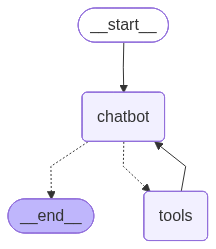

In [15]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 정의된 조건 함수 사용
)
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile(checkpointer=memory)
graph_with_tools

In [16]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "LangGraph use cases 2025", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://community.latenode.com/t/still-worth-using-langgraph-and-langsmith-combo-in-2025/36590", "title": "Still worth using LangGraph and LangSmith combo in 2025?", "content": "# Still worth using LangGraph and LangSmith combo in 2025? But I have to admit that LangGraph and LangSmith bring some real value to the table. Is anyone out there still using LangGraph mainly for orchestration and managing state? The LangSmith tracing feature looks like it could really help improve quality over time though. The state management is where it really shines, especially for complex workflows where agents need to keep context between interactions. The combo works great when you need to iterate fast on complex agent behavior while keeping solid perf

In [17]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="1+2")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
3
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
1 + 2는 3입니다.

In [18]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="이전 질문이 뭐였지?")]
    },
    config=config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
이전 질문은 "2025년 LangGraph 사용 사례 알려주세요."였습니다.

# 메모리 추가

In [19]:
from typing import List, Optional
from datetime import datetime
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser



class MemoryItem(BaseModel):
    """개별 메모리 아이템"""
    key: str = Field(description="메모리 키(예: user_name, perference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description = "카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0, le=1.0)

class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )

